# Stock Price Prediction with LSTM on Yahoo Finance Dataset

This notebook implements a Long Short-Term Memory (LSTM) network to predict closing stock prices using historical data from Yahoo Finance.

**Key concepts covered:**
- Time-series data preparation & sliding-window sequencing
- Min-max normalization and inverse transform
- Stacked LSTM with dropout regularization
- Multi-step ahead forecasting
- Evaluation with RMSE and MAE

In [10]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import yfinance as yf

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 1) Download Historical Stock Data

We fetch 5 years of daily closing prices for **Apple (AAPL)** using `yfinance`.
Install if needed:
```bash
pip install yfinance
```

[*********************100%***********************]  1 of 1 completed

Downloaded 1509 trading days (2018-01-01 → 2023-12-31)
Price           Close
Ticker           AAPL
Date                 
2018-01-02  40.304173
2018-01-03  40.297153
2018-01-04  40.484329
2018-01-05  40.945259
2018-01-08  40.793190


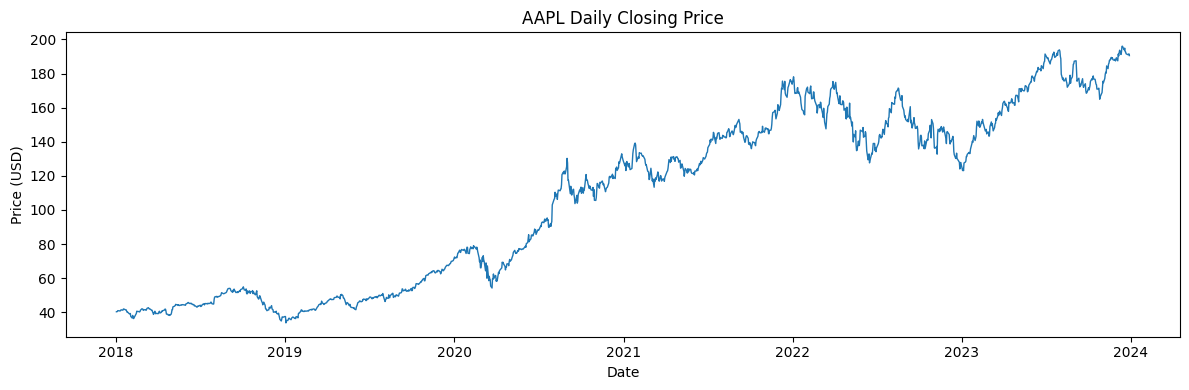

In [11]:
TICKER     = "AAPL"
START_DATE = "2018-01-01"
END_DATE   = "2023-12-31"

df = yf.download(TICKER, start=START_DATE, end=END_DATE, auto_adjust=True)
df = df[["Close"]].dropna()
df.index = pd.to_datetime(df.index)

print(f"Downloaded {len(df)} trading days ({START_DATE} → {END_DATE})")
print(df.head())

plt.figure(figsize=(12, 4))
plt.plot(df.index, df["Close"], linewidth=1)
plt.title(f"{TICKER} Daily Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()

## 2) Preprocessing — Normalization & Sequence Creation

In [12]:
SEQ_LEN    = 60    # use past 60 days to predict next day
TRAIN_FRAC = 0.80  # 80% train, 20% test

prices = df["Close"].values.reshape(-1, 1).astype(np.float32)  # (N, 1)

# Train/test split BEFORE fitting the scaler to avoid data leakage
split = int(len(prices) * TRAIN_FRAC)
train_raw = prices[:split]
test_raw  = prices[split:]

# Min-max normalization fitted on training data only
p_min = train_raw.min()
p_max = train_raw.max()

def normalize(x):
    return (x - p_min) / (p_max - p_min)

def denormalize(x):
    return x * (p_max - p_min) + p_min

train_norm = normalize(train_raw)  # (N_train, 1)
test_norm  = normalize(test_raw)   # (N_test,  1)

print(f"Train samples: {len(train_norm)}  |  Test samples: {len(test_norm)}")
print(f"Price range (train): {p_min:.2f} – {p_max:.2f}")

def make_sequences(data, seq_len):
    """Build (X, y) sliding-window sequences from a 1-D normalized array."""
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])          # (seq_len, 1)
        y.append(data[i + seq_len])              # (1,)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# For test sequences we need the last SEQ_LEN train points as context
full_norm    = normalize(prices)
X_train, y_train = make_sequences(full_norm[:split],          SEQ_LEN)
X_test,  y_test  = make_sequences(full_norm[split - SEQ_LEN:], SEQ_LEN)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

Train samples: 1207  |  Test samples: 302
Price range (train): 33.77 – 178.10
X_train: (1147, 60, 1)  y_train: (1147, 1)
X_test:  (302, 60, 1)   y_test:  (302, 1)


## 3) Dataset & DataLoader

In [13]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)  # (N, seq_len, 1)
        self.y = torch.from_numpy(y)  # (N, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 32

train_ds = StockDataset(X_train, y_train)
test_ds  = StockDataset(X_test,  y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_dl)}  |  Test batches: {len(test_dl)}")
xb, yb = next(iter(train_dl))
print("Batch X shape:", xb.shape, "  Batch y shape:", yb.shape)

Train batches: 36  |  Test batches: 10
Batch X shape: torch.Size([32, 60, 1])   Batch y shape: torch.Size([32, 1])


## 4) Stacked LSTM Model

Architecture:
```
Input (seq_len, 1)  →  LSTM layer 1  →  LSTM layer 2  →  Dropout  →  FC(hidden→1)
```

We take only the **last hidden state** of the final LSTM layer as a summary of the entire sequence and pass it to a fully-connected head.

In [14]:
class StockLSTM(nn.Module):
    """
    Stacked LSTM for univariate time-series regression.

    Parameters
    ----------
    input_size   : number of features per time step (1 for univariate)
    hidden_size  : number of LSTM hidden units per layer
    num_layers   : number of stacked LSTM layers
    dropout      : dropout applied between LSTM layers (and before FC)
    """

    def __init__(
        self,
        input_size: int  = 1,
        hidden_size: int = 64,
        num_layers: int  = 2,
        dropout: float   = 0.2,
    ):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (B, seq_len, input_size)
        # Initialize hidden and cell states to zero
        B = x.size(0)
        h0 = torch.zeros(self.num_layers, B, self.hidden_size, device=x.device)
        c0 = torch.zeros(self.num_layers, B, self.hidden_size, device=x.device)

        out, _ = self.lstm(x, (h0, c0))  # out: (B, seq_len, hidden_size)
        last    = out[:, -1, :]          # (B, hidden_size) — last time step
        last    = self.dropout(last)
        return self.fc(last)             # (B, 1)


model = StockLSTM(
    input_size  = 1,
    hidden_size = 64,
    num_layers  = 2,
    dropout     = 0.2,
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

StockLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Trainable parameters: 50,497


## 5) Training & Evaluation Utilities

In [15]:
def train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss, total = 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        pred = model(x)          # (B, 1)
        loss = loss_fn(pred, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        total      += y.size(0)
    return total_loss / total


@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss, total = 0.0, 0
    all_preds, all_targets = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)
        loss = loss_fn(pred, y)
        total_loss += loss.item() * y.size(0)
        total      += y.size(0)
        all_preds.append(pred.cpu().numpy())
        all_targets.append(y.cpu().numpy())
    preds   = np.concatenate(all_preds)
    targets = np.concatenate(all_targets)
    return total_loss / total, preds, targets


def compute_metrics(preds_norm, targets_norm):
    """RMSE and MAE in original price scale."""
    preds   = denormalize(preds_norm)
    targets = denormalize(targets_norm)
    rmse = np.sqrt(np.mean((preds - targets) ** 2))
    mae  = np.mean(np.abs(preds - targets))
    return rmse, mae


def train(
    model, train_loader, test_loader,
    epochs=50, lr=1e-3
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )
    loss_fn = nn.MSELoss()

    history = {"train_loss": [], "test_loss": [], "rmse": [], "mae": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss                     = train_epoch(model, train_loader, optimizer, loss_fn)
        te_loss, preds, targets     = evaluate(model, test_loader, loss_fn)
        rmse, mae                   = compute_metrics(preds, targets)
        scheduler.step(te_loss)

        history["train_loss"].append(tr_loss)
        history["test_loss"].append(te_loss)
        history["rmse"].append(rmse)
        history["mae"].append(mae)

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"Epoch {epoch:03d}/{epochs}  "
                f"train MSE={tr_loss:.6f}  |  "
                f"test  MSE={te_loss:.6f}  RMSE=${rmse:.2f}  MAE=${mae:.2f}  "
                f"[{time.time()-t0:.1f}s]"
            )

    return history

## 6) Train the Model

In [16]:
history = train(
    model, train_dl, test_dl,
    epochs=50,
    lr=1e-3,
)

best_idx  = int(np.argmin(history["rmse"]))
print(f"\nBest RMSE: ${history['rmse'][best_idx]:.2f}  (epoch {best_idx+1})")
print(f"Best MAE:  ${history['mae'][best_idx]:.2f}  (epoch {best_idx+1})")

Epoch 001/50  train MSE=0.133617  |  test  MSE=0.067053  RMSE=$37.38  MAE=$35.31  [0.5s]
Epoch 010/50  train MSE=0.003463  |  test  MSE=0.003071  RMSE=$8.00  MAE=$7.00  [0.1s]
Epoch 020/50  train MSE=0.002635  |  test  MSE=0.001392  RMSE=$5.39  MAE=$4.55  [0.1s]
Epoch 030/50  train MSE=0.002246  |  test  MSE=0.002476  RMSE=$7.18  MAE=$6.32  [0.1s]
Epoch 040/50  train MSE=0.002005  |  test  MSE=0.001258  RMSE=$5.12  MAE=$4.36  [0.1s]
Epoch 050/50  train MSE=0.001990  |  test  MSE=0.001713  RMSE=$5.97  MAE=$5.18  [0.1s]

Best RMSE: $4.57  (epoch 27)
Best MAE:  $3.50  (epoch 27)


## 7) Plot Training Curves

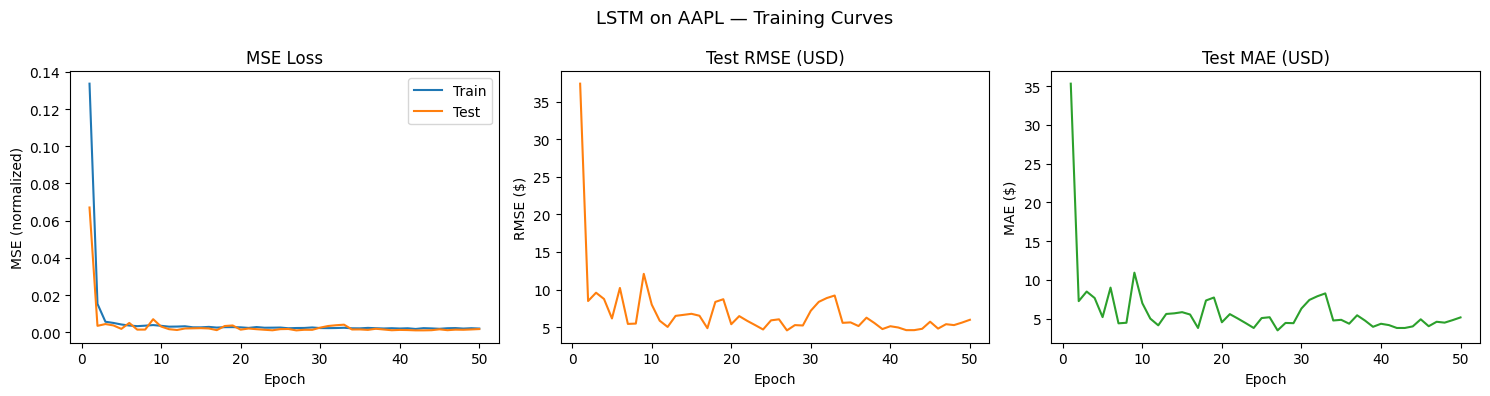

In [17]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["test_loss"],  label="Test")
axes[0].set_title("MSE Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE (normalized)")
axes[0].legend()

axes[1].plot(epochs_range, history["rmse"], color="tab:orange")
axes[1].set_title("Test RMSE (USD)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE ($)")

axes[2].plot(epochs_range, history["mae"], color="tab:green")
axes[2].set_title("Test MAE (USD)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("MAE ($)")

fig.suptitle(f"LSTM on {TICKER} — Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

## 8) Predicted vs Actual Closing Price

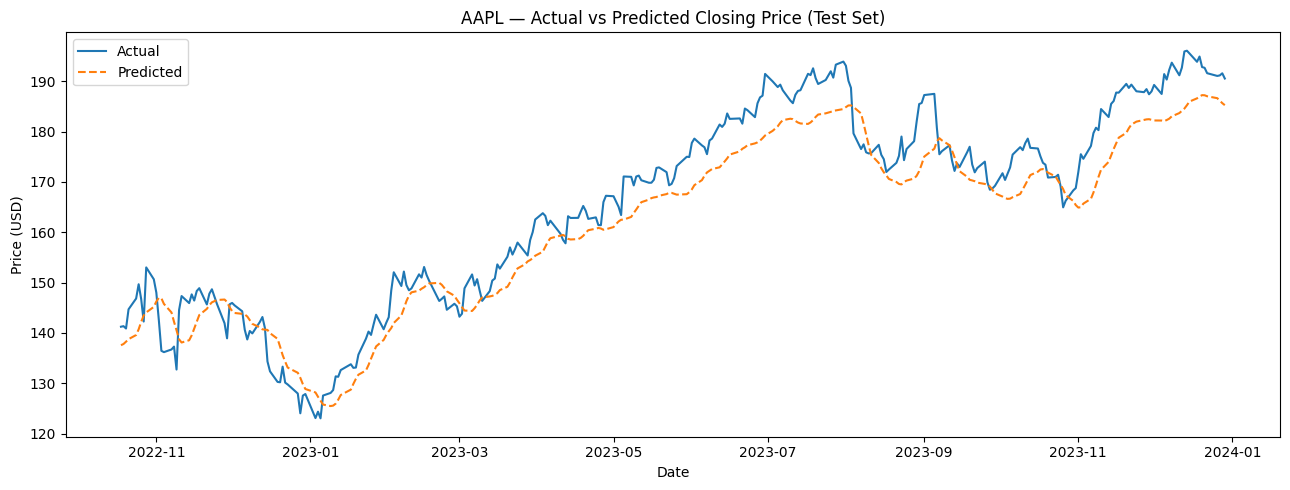

Final Test RMSE: $5.97
Final Test MAE:  $5.18


In [18]:
_, preds_norm, targets_norm = evaluate(model, test_dl, nn.MSELoss())

preds_price   = denormalize(preds_norm).flatten()
targets_price = denormalize(targets_norm).flatten()

# Align with dates
test_dates = df.index[split:]

plt.figure(figsize=(13, 5))
plt.plot(test_dates, targets_price, label="Actual",    linewidth=1.5)
plt.plot(test_dates, preds_price,   label="Predicted", linewidth=1.5, linestyle="--")
plt.title(f"{TICKER} — Actual vs Predicted Closing Price (Test Set)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

rmse_final, mae_final = compute_metrics(preds_norm, targets_norm)
print(f"Final Test RMSE: ${rmse_final:.2f}")
print(f"Final Test MAE:  ${mae_final:.2f}")

## 9) Ablation: Effect of Hidden Size & Number of Layers

In [19]:
configs = [
    {"hidden_size": 32,  "num_layers": 1, "label": "hidden=32, layers=1"},
    {"hidden_size": 64,  "num_layers": 1, "label": "hidden=64, layers=1"},
    {"hidden_size": 64,  "num_layers": 2, "label": "hidden=64, layers=2"},
    {"hidden_size": 128, "num_layers": 2, "label": "hidden=128, layers=2"},
]

ABLATION_EPOCHS = 30
loss_fn = nn.MSELoss()
results = []

for cfg in configs:
    print(f"\n--- {cfg['label']} ---")
    m = StockLSTM(
        input_size  = 1,
        hidden_size = cfg["hidden_size"],
        num_layers  = cfg["num_layers"],
        dropout     = 0.2,
    ).to(device)
    h = train(m, train_dl, test_dl, epochs=ABLATION_EPOCHS, lr=1e-3)
    _, p, t = evaluate(m, test_dl, loss_fn)
    rmse, mae = compute_metrics(p, t)
    results.append({"label": cfg["label"], "rmse": rmse, "mae": mae, "history": h})
    print(f"RMSE=${rmse:.2f}  MAE=${mae:.2f}")


--- hidden=32, layers=1 ---
Epoch 001/30  train MSE=0.152888  |  test  MSE=0.067601  RMSE=$37.53  MAE=$34.65  [0.1s]
Epoch 010/30  train MSE=0.004558  |  test  MSE=0.003817  RMSE=$8.92  MAE=$7.64  [0.1s]
Epoch 020/30  train MSE=0.003712  |  test  MSE=0.001359  RMSE=$5.32  MAE=$4.30  [0.1s]
Epoch 030/30  train MSE=0.002878  |  test  MSE=0.002087  RMSE=$6.59  MAE=$5.71  [0.1s]
RMSE=$6.59  MAE=$5.71

--- hidden=64, layers=1 ---
Epoch 001/30  train MSE=0.126012  |  test  MSE=0.141342  RMSE=$54.26  MAE=$52.58  [0.1s]
Epoch 010/30  train MSE=0.002604  |  test  MSE=0.001267  RMSE=$5.14  MAE=$4.37  [0.1s]
Epoch 020/30  train MSE=0.002090  |  test  MSE=0.002352  RMSE=$7.00  MAE=$6.16  [0.1s]
Epoch 030/30  train MSE=0.001944  |  test  MSE=0.002157  RMSE=$6.70  MAE=$5.91  [0.1s]
RMSE=$6.70  MAE=$5.91

--- hidden=64, layers=2 ---
Epoch 001/30  train MSE=0.099519  |  test  MSE=0.002969  RMSE=$7.87  MAE=$6.86  [0.1s]
Epoch 010/30  train MSE=0.002867  |  test  MSE=0.001198  RMSE=$5.00  MAE=$4.09  [0

Config                      RMSE ($)    MAE ($)
------------------------------------------------
hidden=32, layers=1             6.59       5.71
hidden=64, layers=1             6.70       5.91
hidden=64, layers=2             5.98       5.10
hidden=128, layers=2            5.51       4.77


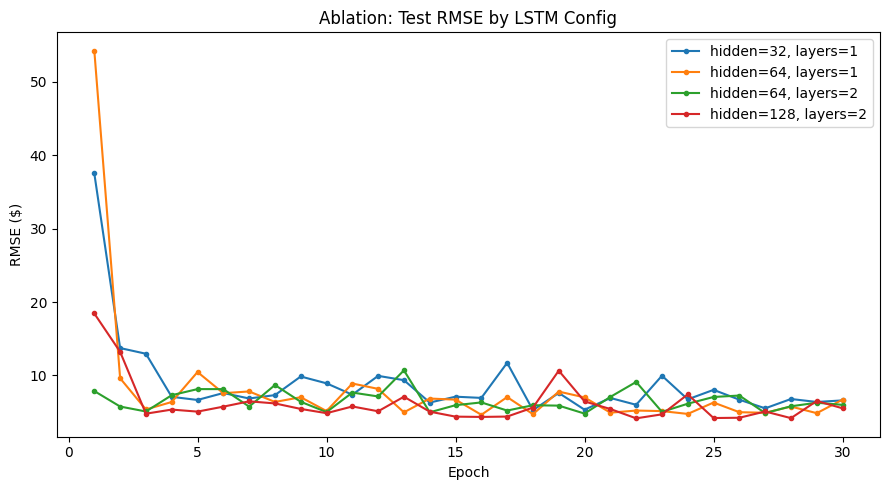

In [20]:
# Summary table
print(f"{'Config':<25} {'RMSE ($)':>10} {'MAE ($)':>10}")
print("-" * 48)
for r in results:
    print(f"{r['label']:<25} {r['rmse']:>10.2f} {r['mae']:>10.2f}")

# Plot RMSE curves for all configs
plt.figure(figsize=(9, 5))
for r in results:
    plt.plot(range(1, ABLATION_EPOCHS + 1), r["history"]["rmse"], marker="o", markersize=3, label=r["label"])
plt.title("Ablation: Test RMSE by LSTM Config")
plt.xlabel("Epoch")
plt.ylabel("RMSE ($)")
plt.legend()
plt.tight_layout()
plt.show()

## Summary

| Component | Detail |
|---|---|
| Dataset | Yahoo Finance — AAPL daily Close (2018–2023, ~1,508 days) |
| Sequence length | 60 trading days (≈ 3 months of context) |
| Normalization | Min-max scaling fitted on training set only |
| Architecture | Stacked LSTM (2 layers × 64 hidden) + Dropout(0.2) + FC |
| Loss | MSE on normalized prices |
| Optimizer | Adam (lr=1e-3) with ReduceLROnPlateau |
| Gradient clipping | max_norm=1.0 |
| Evaluation | RMSE and MAE in original USD scale |

**Why LSTM for time series:**  
Standard RNNs suffer from vanishing gradients over long sequences. LSTM's gating mechanism (input, forget, output gates) allows gradients to flow across hundreds of time steps, making it well-suited for capturing multi-week trends and seasonal patterns in stock prices.